# Part 4e — Policy instruments

### Tariffs, quotas and local content, as exogenous levers

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/USERNAME/lithium-modelling/blob/main/notebooks/04e_policy.ipynb)

Every model so far has had firms responding only to each other. Here a government
sets a lever first, and the firms re-optimise inside the world it creates. The
levers are **exogenous** — chosen and swept, never optimised — because the point
is to measure what each one does, not to solve for a best policy.

Three instruments, and the whole notebook turns on the differences between them:

| | what it does | who collects the rent |
|---|---|---|
| **Tariff** | per-unit duty on imports | the **importing government** |
| **Quota** | per-period cap on imports | whoever holds the licence — here, the firms |
| **Local content** | floor on the domestic firm's own-market sales | nobody; it is not a transfer at all |

**Note who pays what**, because it is what makes the welfare arithmetic
interesting. A tariff is a cost to the **exporting firm** and revenue to the
**importing government**, so it enters the welfare sum twice with opposite signs
and nets out — leaving only the behavioural change it induces. A quota induces a
similar behavioural change and collects nothing. That asymmetry is the entire
textbook case for preferring tariffs to quotas, and section 10 reproduces it from
a supply chain model rather than assuming it.

The third instrument is different in kind, and section 11 is where that matters:
a tariff or quota raises a **rival's** cost, while a local content floor
constrains **your own** firm's optimisation.

### How to read this notebook

Sections 6 and 7 are this notebook's lesson and are built by hand: the three
policy blocks attached to a firm's problem, and the welfare accounting. Section 5
**carries over** the supply chain, the Cournot machinery and the MPEC from Parts
4c and 4d, where each is taught. Section 8 wraps the policy model once you have
built one, and section 13 asserts the notebook and the `lithium` package agree to
$10^{-9}$.

## 0. Setup

One cell, and it is the only place the `lithium` package appears before the final check. On Colab it
clones the repo and installs it; locally it assumes you have already run `pip install -e .` and just
moves up out of `notebooks/` so the relative data paths work.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/USERNAME/lithium-modelling.git"   # <-- edit me
REPO_NAME = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")

if "google.colab" in sys.modules:
    if not Path(REPO_NAME).exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_NAME)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)
elif Path.cwd().name == "notebooks":
    os.chdir("..")

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"font.size": 12, "axes.grid": True, "grid.alpha": 0.3})
print(f"working directory : {Path.cwd().name}")
print(f"gurobipy          : {gp.gurobi.version()}")
print(f"pandas            : {pd.__version__}")

working directory : Advanced Opt Modeling Examples
gurobipy          : (13, 0, 2)
pandas            : 2.3.3


## 2. The instance tables

Two kinds of number go into this model and they are treated differently.

A **knob** is a scalar carrying a concept — the discount rate, the number of revenue breakpoints,
the choke price. Knobs stay written out in the cell where they are explained, because seeing
`NBP_REV = 7` next to the sentence describing what a breakpoint mesh does *is* the lesson. This
notebook hands every knob to the package explicitly in section 13, so the agreement assertion covers
them.

A **table** is instance data — many entries, indexed by the model's own sets, named nowhere in the
prose. Tables live in `data/raw/`, and both this notebook and `src/lithium/` read the same file. If
each typed its own copy, a failed assertion could not tell a typo in the data from a bug in a
constraint. Three tables, three key structures:

| file | keyed by | rows |
|---|---|---|
| `instance_base.csv` | `(stage, region)` | 6 |
| `efficiency.csv` | `stage` | 3 |
| `market.csv` | `region` | 2 |

Read the base table first and look at it as a **frame** — rows and columns — before turning it into
anything the model can index.

In [2]:
DATA = Path("data/raw")

if not (DATA / "instance_base.csv").exists():
    print("!" * 78)
    print("! data/raw/ was not found, so this notebook is FALLING BACK to generated")
    print("! numbers. Everything below will run and every figure will render, but the")
    print("! results are NOT the shipped instance and are NOT an acceptable submission.")
    print("! Fix: clone the repo (see section 0) or run this notebook from the repo root.")
    print("!" * 78)
    DATA = Path("_generated_fallback")
    DATA.mkdir(exist_ok=True)
    (DATA / "instance_base.csv").write_text(
        "stage,region,fixed,unit,opex,legacy_cap,legacy_ret\n"
        + "\n".join(f"{s},{r},1000.0,8.0,2.0,150,15"
                    for r in ("R1", "R2") for s in ("MINE", "PROC", "MFG")) + "\n")
    (DATA / "efficiency.csv").write_text(
        "stage,eta_ceil,eta_base,alpha,beta,delta_bar\n"
        "MINE,0.92,0.86,0.0,0.0,0.02\nPROC,0.95,0.80,0.03,0.01,0.05\n"
        "MFG,0.93,0.78,0.025,0.008,0.05\n")
    (DATA / "market.csv").write_text(
        "region,demand_base,demand_growth,experience0\n"
        "R1,100.0,0.008,1000.0\nR2,75.0,0.026,1000.0\n")

base = pd.read_csv(DATA / "instance_base.csv")
print(f"instance_base.csv: {len(base)} rows x {len(base.columns)} columns")
base

instance_base.csv: 6 rows x 7 columns


,stage,region,fixed,unit,opex,legacy_cap,legacy_ret
0,MINE,R1,900.0,7.0,1.20,230,11
1,PROC,R1,1500.0,11.0,2.00,205,14
2,MFG,R1,1300.0,9.5,2.40,155,18
3,MINE,R2,820.0,6.4,1.35,165,9
4,PROC,R2,1350.0,10.0,2.20,125,16
5,MFG,R2,1180.0,8.7,2.60,100,22


The other two tables. `efficiency.csv` is keyed by stage alone — a mine's yield behaviour does not
depend on which region owns it — and `market.csv` is keyed by region alone.

In [3]:
eff = pd.read_csv(DATA / "efficiency.csv")
mkt = pd.read_csv(DATA / "market.csv")
print(f"efficiency.csv: {len(eff)} rows    market.csv: {len(mkt)} rows")
display(eff)
mkt

efficiency.csv: 3 rows    market.csv: 2 rows


,stage,eta_ceil,eta_base,alpha,beta,delta_bar
0,MINE,0.92,0.86,0.000,0.000,0.02
1,PROC,0.95,0.80,0.030,0.010,0.05
2,MFG,0.93,0.78,0.025,0.008,0.05


,region,demand_base,demand_growth,experience0
0,R1,100.0,0.008,2600.0
1,R2,75.0,0.026,500.0


### 2.1 From table to lookup — see the key

A frame shows rows and columns. **The model does not index by row number.** Every constraint below
looks a value up by a *key*: `FIXED['PROC', 'R1']`, `ETA_CEIL['MFG']`, `EXPERIENCE0['R2']`. That key
is what connects the data to the algebra, so build the dictionaries and print them in the form the
constraints will actually use, rather than leaving the index set implied by punctuation.

The two index sets come out of the tables themselves, in file order — so the order the model
iterates in is a property of the data, not of a sorted() call somewhere.

In [4]:
STAGES = list(dict.fromkeys(eff["stage"]))
REGIONS = list(dict.fromkeys(mkt["region"]))

FIXED = {(r.stage, r.region): r.fixed for r in base.itertuples()}
UNIT = {(r.stage, r.region): r.unit for r in base.itertuples()}
OPEX = {(r.stage, r.region): r.opex for r in base.itertuples()}
LEGACY_CAP = {(r.stage, r.region): float(r.legacy_cap) for r in base.itertuples()}
LEGACY_RET = {(r.stage, r.region): int(r.legacy_ret) for r in base.itertuples()}

print(f"index sets:  STAGES  = {STAGES}")
print(f"             REGIONS = {REGIONS}")
print(f"{len(FIXED)} keys, each a (stage, region) tuple\n")
print(f"{'key':18s} {'FIXED':>8s} {'UNIT':>7s} {'OPEX':>6s} {'LEG_CAP':>8s} {'LEG_RET':>8s}")
for s in STAGES:
    for r in REGIONS:
        print(f"{str((s, r)):18s} {FIXED[s, r]:8.1f} {UNIT[s, r]:7.2f} {OPEX[s, r]:6.2f}"
              f" {LEGACY_CAP[s, r]:8.0f} {LEGACY_RET[s, r]:8d}")

index sets:  STAGES  = ['MINE', 'PROC', 'MFG']
             REGIONS = ['R1', 'R2']
6 keys, each a (stage, region) tuple

key                   FIXED    UNIT   OPEX  LEG_CAP  LEG_RET
('MINE', 'R1')        900.0    7.00   1.20      230       11
('MINE', 'R2')        820.0    6.40   1.35      165        9
('PROC', 'R1')       1500.0   11.00   2.00      205       14
('PROC', 'R2')       1350.0   10.00   2.20      125       16
('MFG', 'R1')        1300.0    9.50   2.40      155       18
('MFG', 'R2')        1180.0    8.70   2.60      100       22


The same move for the two single-key tables. Note `EXPERIENCE0`: R1 starts with 2,600 units of
accumulated production experience against R2's 500. Nothing in this instance is labelled
"incumbent" — that word is a *reading* of three numbers pulling the same way: R1 starts with more
experience, larger inherited plants, and the bigger home market. R2's compensating advantage is in
`instance_base.csv`, and it is capital, not operating cost: R2 is cheaper to **build** at every stage
and more expensive to **run** at every stage. Check that against the table above before going on,
because most of the results below turn on it.

In [5]:
ETA_CEIL = {r.stage: r.eta_ceil for r in eff.itertuples()}
ETA_BASE = {r.stage: r.eta_base for r in eff.itertuples()}
ALPHA = {r.stage: r.alpha for r in eff.itertuples()}
BETA = {r.stage: r.beta for r in eff.itertuples()}
DELTA_BAR = {r.stage: r.delta_bar for r in eff.itertuples()}

DEMAND_BASE = {r.region: r.demand_base for r in mkt.itertuples()}
DEMAND_GROWTH = {r.region: r.demand_growth for r in mkt.itertuples()}
EXPERIENCE0 = {r.region: r.experience0 for r in mkt.itertuples()}

print("keyed by stage :")
for s in STAGES:
    print(f"  {s!r:8s} ceil {ETA_CEIL[s]:.2f}  base {ETA_BASE[s]:.2f}  alpha {ALPHA[s]:.3f}"
          f"  beta {BETA[s]:.3f}  delta_bar {DELTA_BAR[s]:.2f}")
print("\nkeyed by region:")
for r in REGIONS:
    print(f"  {r!r:6s} demand_base {DEMAND_BASE[r]:6.1f}  growth {DEMAND_GROWTH[r]:.3f}"
          f"  experience0 {EXPERIENCE0[r]:7.1f}")

keyed by stage :
  'MINE'   ceil 0.92  base 0.86  alpha 0.000  beta 0.000  delta_bar 0.02
  'PROC'   ceil 0.95  base 0.80  alpha 0.030  beta 0.010  delta_bar 0.05
  'MFG'    ceil 0.93  base 0.78  alpha 0.025  beta 0.008  delta_bar 0.05

keyed by region:
  'R1'   demand_base  100.0  growth 0.008  experience0  2600.0
  'R2'   demand_base   75.0  growth 0.026  experience0   500.0


### 2.2 Want to experiment? Change a number here, not in the CSV

Each table is now a dictionary keyed the way the model indexes. Assign to a key to override one
entry. The change flows into every model built below **and** into the section 13 agreement check,
because the package takes the data as an argument instead of re-reading the file — so the assertion
stays green and you can see exactly what your edit did.

In [6]:
# ---------------------------------------------------------------------------
# Example - give R2 the same processing opex as R1 (2.0 instead of its 2.2):
#
#     OPEX['PROC', 'R2'] = 2.00
#
# Uncomment, then re-run this cell and everything below it. This erases R1's
# operating-cost edge at the processing stage, so R2 gets cheaper to run, its
# equilibrium share rises, and the section 13 assertion stays green because the
# notebook passes OPEX to the package rather than letting it re-read the file.
# Re-run with it commented out to get the shipped instance back.
# ---------------------------------------------------------------------------
print(f"OPEX['PROC', 'R2'] is currently {OPEX['PROC', 'R2']}")

OPEX['PROC', 'R2'] is currently 2.2


## 3. The knobs, and the structure derived from them

Everything from here to section 5 is **derived**: sets, windows, discount weights, yields. None of
it is data and none of it is a knob — it is arithmetic on the two, and doing that arithmetic is the
point of this section. `src/lithium/structure.py` computes exactly the same things, and section 13
is what proves the two derivations agree.

### 3.1 Time: variable-length periods

A 37-year horizon at annual resolution would be 37 copies of every decision. Instead the horizon is
chopped into **13 periods of increasing length** — six 1-year periods while the interesting things
happen, then 3-, 5- and finally 9-year blocks. `OMEGA[p]` is the sum of discount factors for the
years inside period `p`, so a long late period is correctly worth less per year *and* covers more
years. The cell prints the block structure it actually built, so you can check it against whatever
`BLOCKS` says rather than against this paragraph.

In [7]:
BLOCKS = [(6, 1), (4, 3), (2, 5), (1, 9)]   # (how many periods, how many years each)
DR = 0.05                                    # discount rate

LEN, START = [], []
_y = 1
for _count, _length in BLOCKS:
    for _ in range(_count):
        LEN.append(_length)
        START.append(_y)
        _y += _length

P = list(range(len(LEN)))
HORIZON = _y - 1
YEARS = {p: list(range(START[p], START[p] + LEN[p])) for p in P}
OMEGA = {p: sum(1 / (1 + DR) ** t for t in YEARS[p]) for p in P}
YEAR_TO_P = {t: p for p in P for t in YEARS[p]}

print(f"{len(P)} periods covering {HORIZON} years")
print(f"{'p':>3s} {'start':>6s} {'len':>4s} {'OMEGA':>8s}")
for p in P:
    print(f"{p:3d} {START[p]:6d} {LEN[p]:4d} {OMEGA[p]:8.4f}")

13 periods covering 37 years
  p  start  len    OMEGA
  0      1    1   0.9524
  1      2    1   0.9070
  2      3    1   0.8638
  3      4    1   0.8227
  4      5    1   0.7835
  5      6    1   0.7462
  6      7    3   2.0321
  7     10    3   1.7554
  8     13    3   1.5164
  9     16    3   1.3099
 10     19    5   1.7990
 11     24    5   1.4096
 12     29    9   1.8132


### 3.2 Technology: turning a lump of capex into an annual charge

A plant built in period `v` is paid for once and used for `LIFE` years. `CRF` is the capital
recovery factor that spreads that lump into equal annual payments, and `MU[s, v]` discounts those
payments back to today — truncated at the horizon, so a plant built late gets credit only for the
years that actually fall inside the model.

`LEAD` is the construction lag: decide in period `v`, produce from `START[v] + LEAD[s]`.

In [8]:
LIFE = 25
LEAD = {'MINE': 1, 'PROC': 2, 'MFG': 2}
CAP_MIN, CAP_MAX = 60.0, 260.0

CRF = DR * (1 + DR) ** LIFE / ((1 + DR) ** LIFE - 1)
ONLINE = {(s, p): START[p] + LEAD[s] for s in STAGES for p in P}
MU = {(s, v): CRF * sum(1 / (1 + DR) ** t
                        for t in range(ONLINE[s, v], ONLINE[s, v] + LIFE)
                        if t <= HORIZON)
      for s in STAGES for v in P}

print(f"CRF = {CRF:.6f}   (a 1.0 lump becomes {CRF:.4f} per year for {LIFE} years)")
print(f"\nMU['PROC', v] by build period - note the collapse as v approaches the horizon:")
print("  " + "  ".join(f"v{v}:{MU['PROC', v]:5.2f}" for v in P))

CRF = 0.070952   (a 1.0 lump becomes 0.0710 per year for 25 years)

MU['PROC', v] by build period - note the collapse as v approaches the horizon:
  v0: 0.91  v1: 0.86  v2: 0.82  v3: 0.78  v4: 0.75  v5: 0.71  v6: 0.68  v7: 0.58  v8: 0.48  v9: 0.39  v10: 0.30  v11: 0.19  v12: 0.09


### 3.3 Efficiency: yield depends on when a plant was built and how old it is

Two effects, and they pull in opposite directions. A plant built later starts closer to the
technological ceiling (`ALPHA` — the frontier improves). A plant that has been running for a while
also drifts up towards the ceiling through operating experience (`BETA`), but only by at most
`DELTA_BAR` above where it started. `ETA_FLOOR` stops the arithmetic producing a nonsense yield.

`LEGACY_BYR = -8` says the inherited plants were built eight years before year 1 — which is why they
sit well below the frontier.

In [9]:
ETA_FLOOR = 0.60
LEGACY_BYR = -8

VINTAGES = [-1] + P                      # -1 is the inherited fleet
BYEAR = {v: (LEGACY_BYR if v == -1 else START[v]) for v in VINTAGES}

ETA = {}
for s in STAGES:
    for v in VINTAGES:
        fr = ETA_CEIL[s] - (ETA_CEIL[s] - ETA_BASE[s]) * (1 - ALPHA[s]) ** (BYEAR[v] - 1)
        fr = max(ETA_FLOOR, min(fr, ETA_CEIL[s]))
        for p in P:
            age = max(0, START[p] - BYEAR[v])
            aged = ETA_CEIL[s] - (ETA_CEIL[s] - fr) * (1 - BETA[s]) ** age
            ETA[s, v, p] = max(ETA_FLOOR, min(fr + DELTA_BAR[s], aged))

print(f"{len(ETA)} yields, keyed (stage, vintage, period)\n")
print("PROC yield in period 0, by vintage - the frontier effect:")
print("  legacy (v=-1): %.4f" % ETA['PROC', -1, 0])
print("  " + "  ".join(f"v{v}:{ETA['PROC', v, 0]:.4f}" for v in P[:5]))
print("\nlegacy PROC plant ageing through the horizon:")
print("  " + "  ".join(f"p{p}:{ETA['PROC', -1, p]:.4f}" for p in P[:6]))

546 yields, keyed (stage, vintage, period)

PROC yield in period 0, by vintage - the frontier effect:
  legacy (v=-1): 0.7698
  v0:0.8000  v1:0.8045  v2:0.8089  v3:0.8131  v4:0.8172

legacy PROC plant ageing through the horizon:
  p0:0.7698  p1:0.7716  p2:0.7733  p3:0.7751  p4:0.7769  p5:0.7786


### 3.4 Demand

Each region's demand grows from its own base at its own rate. R2 is the smaller market but grows
more than three times as fast, which is why the entrant's home turf is worth fighting for later even
though it is worth less now. The value stored is the **average annual** demand across the period, so
it is comparable across periods of different length.

In [10]:
DEMAND = {(r, p): sum(DEMAND_BASE[r] * (1 + DEMAND_GROWTH[r]) ** (t - 1) for t in YEARS[p]) / LEN[p]
          for r in REGIONS for p in P}

print(f"average annual demand ({len(DEMAND)} keys, (region, period)):")
print(f"{'p':>3s} {'year':>5s} " + " ".join(f"{r:>8s}" for r in REGIONS))
for p in P:
    print(f"{p:3d} {START[p]:5d} " + " ".join(f"{DEMAND[r, p]:8.2f}" for r in REGIONS))

average annual demand (26 keys, (region, period)):
  p  year       R1       R2
  0     1   100.00    75.00
  1     2   100.80    76.95
  2     3   101.61    78.95
  3     4   102.42    81.00
  4     5   103.24    83.11
  5     6   104.06    85.27
  6     7   105.74    89.78
  7    10   108.30    96.97
  8    13   110.92   104.73
  9    16   113.60   113.11
 10    19   117.28   125.40
 11    24   122.05   142.57
 12    29   129.07   170.90


### 3.5 Who can produce, when

Three sets that every constraint below indexes over, and they are worth printing rather than
trusting:

- `ACTIVE[r]` — the `(stage, vintage, period)` triples that exist at all: an inherited plant until
  its retirement year, a new plant from the period it comes online until it has run for `LIFE` years.
- `VIN[r, s, p]` — the vintages available at one stage in one period. This is the set the chain
  balance sums over.
- `BUILD[r]` — the `(stage, vintage)` pairs that could be built, i.e. those that come online before
  the horizon ends.

In [11]:
ACTIVE = {r: [(s, v, p) for s in STAGES for v in VINTAGES for p in P
              if (v == -1 and START[p] <= LEGACY_RET[s, r])
              or (v >= 0 and ONLINE[s, v] <= START[p] <= ONLINE[s, v] + LIFE - 1)]
          for r in REGIONS}
VIN = {(r, s, p): [v for (ss, v, pp) in ACTIVE[r] if (ss, pp) == (s, p)]
       for r in REGIONS for s in STAGES for p in P}
BUILD = {r: [(s, v) for s in STAGES for v in P if ONLINE[s, v] <= HORIZON]
         for r in REGIONS}

for r in REGIONS:
    print(f"{r}: {len(ACTIVE[r]):4d} active (stage, vintage, period) triples, "
          f"{len(BUILD[r]):3d} buildable (stage, vintage) pairs")
print(f"\nVIN['R1', 'MFG', p] - vintages that can manufacture, period by period:")
for p in P:
    print(f"  p{p:<2d} {VIN['R1', 'MFG', p]}")

R1:  242 active (stage, vintage, period) triples,  39 buildable (stage, vintage) pairs
R2:  243 active (stage, vintage, period) triples,  39 buildable (stage, vintage) pairs

VIN['R1', 'MFG', p] - vintages that can manufacture, period by period:
  p0  [-1]
  p1  [-1]
  p2  [-1, 0]
  p3  [-1, 0, 1]
  p4  [-1, 0, 1, 2]
  p5  [-1, 0, 1, 2, 3]
  p6  [-1, 0, 1, 2, 3, 4]
  p7  [-1, 0, 1, 2, 3, 4, 5, 6]
  p8  [-1, 0, 1, 2, 3, 4, 5, 6, 7]
  p9  [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
  p10 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  p11 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  p12 [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


### 3.6 The remaining knobs: moving goods and the two penalties

`TRANSPORT` is nearly five times more expensive across regions than within one. That single number
is what makes geography matter — without it the two markets would collapse into one.

In [12]:
TRANSPORT_OWN, TRANSPORT_CROSS = 0.5, 2.4
TRANSPORT = {(rf, rt): (TRANSPORT_OWN if rf == rt else TRANSPORT_CROSS)
             for rf in REGIONS for rt in REGIONS}

PRICE_FIXED = 12.0     # the Part 4b price; kept so 4b's revenue term stays available
PEN_SHORT = 90.0       # planner-only: cost of leaving demand unserved
PEN_DISPOSE = 12.0     # cost of destroying output rather than selling it

print("TRANSPORT, keyed (from, to):")
for k, v in TRANSPORT.items():
    print(f"  {str(k):14s} {v:4.1f}")
print(f"\nPEN_DISPOSE = {PEN_DISPOSE}  <- watch this one: section 10 shows it never binds")

TRANSPORT, keyed (from, to):
  ('R1', 'R1')    0.5
  ('R1', 'R2')    2.4
  ('R2', 'R1')    2.4
  ('R2', 'R2')    0.5

PEN_DISPOSE = 12.0  <- watch this one: section 10 shows it never binds


## 4. The capacity-learning curve

Building capacity gets cheaper the more of it you have built. A learning rate `LR_CAPEX = 0.15`
means unit cost falls 15% per doubling of cumulative capacity, which is the exponent
$-\log_2(1 - 0.15)$.

**The model needs the area under that curve, not the curve itself.** Total spend to go from
`Q_START` to `Q` is the integral of the unit cost over that range — building the 401st unit costs
what the curve says at 401, not what it said at 300. So we integrate numerically (trapezoid rule,
`PANELS` panels) at each of `NBP` breakpoints, and the model interpolates between them.

**This curve is concave and it enters a cost we are *minimising*** — so a chord between two
breakpoints lies *below* the true cumulative cost, and a free convex combination would happily mix
distant breakpoints to claim a discount that does not exist. That is why the model in section 5 adds
**SOS2** here. Compare section 5, where the same concave shape in a *maximisation* needs nothing.

In [13]:
import math

LEARN_STAGES = ['PROC', 'MFG']
LR_CAPEX = 0.15        # cost falls 15% per doubling
Q_START = 300.0        # cumulative capacity at which learning starts
Q_ADD = 700.0          # how much further the mesh reaches
CAPEX_FLOOR = 0.60     # the multiplier cannot fall below this
NBP = 9                # breakpoints on the capex mesh
PANELS = 400           # trapezoid panels per breakpoint

_bc = -math.log2(1 - LR_CAPEX)
K = list(range(NBP))                     # the breakpoint index the model sums over
QBP = [Q_START + Q_ADD * k / (NBP - 1) for k in K]

CBP = []
for q in QBP:
    if q <= Q_START:
        CBP.append(0.0)
        continue
    h = (q - Q_START) / PANELS
    grid = [Q_START + i * h for i in range(PANELS + 1)]
    unit = [max(CAPEX_FLOOR, (g / Q_START) ** (-_bc)) for g in grid]
    CBP.append(sum(0.5 * (unit[i] + unit[i + 1]) * h for i in range(PANELS)))

print(f"learning exponent b = {_bc:.4f}\n")
print(f"{'k':>2s} {'QBP (cum capacity)':>19s} {'unit mult':>10s} {'CBP (cum spend mult)':>21s}")
for k in range(NBP):
    print(f"{k:2d} {QBP[k]:19.1f} {max(CAPEX_FLOOR, (QBP[k] / Q_START) ** (-_bc)):10.4f}"
          f" {CBP[k]:21.2f}")

learning exponent b = 0.2345

 k  QBP (cum capacity)  unit mult  CBP (cum spend mult)
 0               300.0     1.0000                  0.00
 1               387.5     0.9418                 84.82
 2               475.0     0.8979                165.22
 3               562.5     0.8630                242.20
 4               650.0     0.8342                316.42
 5               737.5     0.8099                388.32
 6               825.0     0.7888                458.24
 7               912.5     0.7704                526.44
 8              1000.0     0.7541                593.12


## 5. Carried over from Parts 4c and 4d

Everything under this heading is taught elsewhere and reproduced here so the
notebook runs standalone. Four blocks, all marked:

- **the chain** — 04c sections 5 and 7
- **the planner and the tier calibration** — 04c sections 5.7 and 6
- **the Cournot best response and iteration** — 04c sections 7 and 9
- **the Stackelberg MPEC** — 04d sections 8 to 10

Read those notebooks first if you have not. Nothing below this heading is new,
and section 6 is where this notebook starts.

**One thing to notice in `chain()` as it goes past:** it takes no policy
arguments at all. The three levers are attached from *outside* it in section 6,
which is why they are visible rather than buried.

In [14]:
# CARRIED OVER FROM 04c SECTIONS 5 AND 7 - narrated there, not re-taught here.

def chain(m, r, learning, tiers, rev_price):
    """Attach region r's chain to model m. See 04c sections 5.1-5.6 and 7.3-7.4."""
    b_ = m.addVars(BUILD[r], vtype=GRB.BINARY, name=f'b_{r}')
    c_ = m.addVars(BUILD[r], lb=0.0, ub=CAP_MAX, name=f'c_{r}')
    x_ = m.addVars(ACTIVE[r], lb=0.0, name=f'x_{r}')
    fmp_ = m.addVars(P, lb=0.0, name=f'fmp_{r}')
    fpf_ = m.addVars(P, lb=0.0, name=f'fpf_{r}')
    sale_ = m.addVars(REGIONS, P, lb=0.0, name=f'sale_{r}')
    disp_ = m.addVars(P, lb=0.0, name=f'disp_{r}')

    m.addConstrs((c_[s, v] <= CAP_MAX * b_[s, v] for (s, v) in BUILD[r]), name=f'su_{r}')
    m.addConstrs((c_[s, v] >= CAP_MIN * b_[s, v] for (s, v) in BUILD[r]), name=f'sl_{r}')
    m.addConstrs((x_[s, v, p] <= (LEGACY_CAP[s, r] if v == -1 else c_[s, v])
                  for (s, v, p) in ACTIVE[r]), name=f'cap_{r}')
    m.addConstrs((gp.quicksum(ETA['MINE', v, p] * x_['MINE', v, p]
                              for v in VIN[r, 'MINE', p]) == fmp_[p] for p in P), name=f'mine_{r}')
    m.addConstrs((fmp_[p] == gp.quicksum(x_['PROC', v, p] for v in VIN[r, 'PROC', p])
                  for p in P), name=f'pin_{r}')
    m.addConstrs((gp.quicksum(ETA['PROC', v, p] * x_['PROC', v, p]
                              for v in VIN[r, 'PROC', p]) == fpf_[p] for p in P), name=f'pout_{r}')
    m.addConstrs((fpf_[p] == gp.quicksum(x_['MFG', v, p] for v in VIN[r, 'MFG', p])
                  for p in P), name=f'min_{r}')
    m.addConstrs((gp.quicksum(ETA['MFG', v, p] * x_['MFG', v, p] for v in VIN[r, 'MFG', p])
                  == sale_.sum('*', p) + disp_[p] for p in P), name=f'mout_{r}')

    cum_ = m.addVars(P, lb=0.0, ub=3 * CAP_MAX * HORIZON + EXPERIENCE0[r], name=f'cum_{r}')
    m.addConstrs((cum_[p] == EXPERIENCE0[r] +
                  gp.quicksum(LEN[q] * x_['MFG', v, q] for q in P if q <= p
                              for v in VIN[r, 'MFG', q]) for p in P), name=f'cp_{r}')

    capex_ = (gp.quicksum(MU[s, v] * FIXED[s, r] * b_[s, v] for (s, v) in BUILD[r])
              + gp.quicksum(MU[s, v] * UNIT[s, r] * c_[s, v]
                            for (s, v) in BUILD[r] if s not in LEARN_STAGES))
    Q_ = m.addVars(P, lb=Q_START, ub=Q_START + Q_ADD, name=f'Q_{r}')
    C_ = m.addVars(P, lb=0.0, name=f'C_{r}')
    lam_ = m.addVars(P, K, lb=0.0, ub=1.0, name=f'lam_{r}')
    m.addConstrs((lam_.sum(p, '*') == 1 for p in P), name=f'sc_{r}')
    m.addConstrs((Q_[p] == gp.quicksum(QBP[k] * lam_[p, k] for k in K) for p in P), name=f'sQ_{r}')
    m.addConstrs((C_[p] == gp.quicksum(CBP[k] * lam_[p, k] for k in K) for p in P), name=f'sC_{r}')
    m.addConstrs((Q_[p] == Q_START + gp.quicksum(c_[s, v] for (s, v) in BUILD[r]
                                                 if s in LEARN_STAGES and v <= p)
                  for p in P), name=f'cc_{r}')
    for p in P:
        m.addSOS(GRB.SOS_TYPE2, [lam_[p, k] for k in K])
    rate_ = sum(UNIT[s, r] for s in LEARN_STAGES) / len(LEARN_STAGES)
    capex_ += gp.quicksum(MU['PROC', p] * rate_ * (C_[p] - (C_[p - 1] if p > 0 else 0.0))
                          for p in P)

    if learning == 'both' and tiers is not None:
        tq, tm = tiers
        J_ = list(range(N_TIERS))
        z_ = m.addVars(P, J_, vtype=GRB.BINARY, name=f'z_{r}')
        m.addConstrs((z_.sum(p, '*') == 1 for p in P), name=f'ot_{r}')
        lagp = {p: YEAR_TO_P[max(1, START[p] - LAG_YEARS)] for p in P}
        bigq = 3 * CAP_MAX * HORIZON + EXPERIENCE0[r]
        m.addConstrs((cum_[lagp[p]] >= tq[r][j - 1] - bigq * (1 - z_[p, j])
                      for p in P for j in J_ if j > 0), name=f'tf_{r}')
        m.addConstrs((cum_[lagp[p]] <= tq[r][j] + bigq * (1 - z_[p, j])
                      for p in P for j in J_ if j < N_TIERS - 1), name=f'tc_{r}')
        ts_ = m.addVars(STAGES, P, J_, lb=0.0, name=f'ts_{r}')
        m.addConstrs((ts_.sum(s, p, '*') == gp.quicksum(x_[s, v, p] for v in VIN[r, s, p])
                      for s in STAGES for p in P), name=f'tss_{r}')
        m.addConstrs((ts_[s, p, j] <= 3 * CAP_MAX * z_[p, j]
                      for s in STAGES for p in P for j in J_), name=f'tl_{r}')
        opex_ = gp.quicksum(OMEGA[p] * OPEX[s, r] * tm[r][j] * ts_[s, p, j]
                            for s in STAGES for p in P for j in J_)
    else:
        z_ = None
        opex_ = gp.quicksum(OMEGA[p] * OPEX[s, r] * x_[s, v, p] for (s, v, p) in ACTIVE[r])

    trans_ = gp.quicksum(OMEGA[p] * TRANSPORT[r, rt] * sale_[rt, p]
                         for rt in REGIONS for p in P)
    dcost_ = gp.quicksum(OMEGA[p] * PEN_DISPOSE * disp_[p] for p in P)
    rev_ = (gp.quicksum(OMEGA[p] * rev_price * sale_[rt, p] for rt in REGIONS for p in P)
            if rev_price is not None else None)
    return dict(b=b_, c=c_, x=x_, sale=sale_, disp=disp_, cum=cum_, z=z_,
                capex=capex_, opex=opex_, trans=trans_, dcost=dcost_, revenue=rev_,
                cost=capex_ + opex_ + trans_ + dcost_)


print("chain() carried over from 04c - takes NO policy arguments")

chain() carried over from 04c - takes NO policy arguments


### 5.1 The planner, the tiers and inverse demand

In [15]:
# CARRIED OVER FROM 04c SECTIONS 5.7, 6 AND 7.1.

LR_OPEX, OPEX_FLOOR, LAG_YEARS, N_TIERS = 0.18, 0.65, 3, 3
PEN_SHORT, PEN_DISPOSE = 90.0, 12.0
PRICE_FIXED = 12.0
MIPGAP_PLAN = 0.005
CHOKE, P_ANCHOR = 30.0, 13.0


def planner(w1, learning, tiers, mipgap):
    """Cost-minimising planner over both chains. See 04c section 5.7."""
    m = gp.Model()
    m.Params.OutputFlag = 0
    m.Params.MIPGap = mipgap
    H = {r: chain(m, r, learning, tiers, rev_price=None) for r in REGIONS}
    short = m.addVars(REGIONS, P, lb=0.0, name='short')
    m.addConstrs((gp.quicksum(H[r]['sale'][rt, p] for r in REGIONS) + short[rt, p]
                  >= DEMAND[rt, p] for rt in REGIONS for p in P), name='demand')
    pen = gp.quicksum(OMEGA[p] * PEN_SHORT * short[rt, p] for rt in REGIONS for p in P)
    m.setObjective(w1 * H['R1']['cost'] + (1 - w1) * H['R2']['cost'] + pen, GRB.MINIMIZE)
    m.optimize()
    m._H, m._short = H, short
    return m


m0 = planner(0.5, learning='capacity', tiers=None, mipgap=MIPGAP_PLAN)
assert m0.SolCount > 0, f"planner calibration failed; status {m0.Status}"
top = {r: m0._H[r]['cum'][P[-1]].X for r in REGIONS}
TIER_Q, TIER_M = {}, {}
for r in REGIONS:
    _q1 = max(top[r], 1.0) / 8.0
    TIER_Q[r] = [_q1 * 2 ** j for j in range(N_TIERS - 1)]
    TIER_M[r] = [max(OPEX_FLOOR, (1 - LR_OPEX) ** j) for j in range(N_TIERS)]
TIERS = (TIER_Q, TIER_M)

A_INT = {(rt, p): CHOKE for rt in REGIONS for p in P}
B_SLP = {(rt, p): (CHOKE - P_ANCHOR) / DEMAND[rt, p] for rt in REGIONS for p in P}

print(f"planner objective {m0.ObjVal:,.1f}")
for r in REGIONS:
    print(f"  {r}: thresholds {[round(q, 1) for q in TIER_Q[r]]}")

Set parameter Username


Set parameter LicenseID to value 2750151


Academic license - for non-commercial use only - expires 2026-12-04


planner objective 22,023.6
  R1: thresholds [1082.2, 2164.3]
  R2: thresholds [679.4, 1358.8]


### 5.2 The Cournot best response and iteration

Note the signature: `best_response` takes `tariff`, `quota` and `local_min`, and
they default to nothing. That is not carried-over code — it is the **hook**
section 6 fills in. Everything else in these two functions is 04c's.

In [16]:
# CARRIED OVER FROM 04c SECTIONS 7 AND 9, with three policy arguments added.
# Section 6 is where those three arguments earn their keep.

NBP_REV = 7
MIPGAP_GAME, TOL, MAX_ITER = 1e-3, 0.5, 16


def best_response(r, rival, learning, tiers, nbp_rev, mipgap,
                  tariff, quota, local_min):
    """Firm r's profit-maximising reply, under policy. See 04c sections 7.2-7.6
    for everything except the three policy blocks, which are section 6 here."""
    m = gp.Model()
    m.Params.OutputFlag = 0
    m.Params.MIPGap = mipgap
    h = chain(m, r, learning, tiers, rev_price=None)
    s_ = h['sale']

    # ---- the three policy blocks, exactly as written out in section 6 ------
    m.addConstrs((s_[rt, p] <= quota[r, rt] for rt in REGIONS for p in P
                  if (r, rt) in quota), name=f'quota_{r}')
    m.addConstrs((s_[r, p] >= local_min[r] for p in P if r in local_min),
                 name=f'lcr_{r}')
    duty = gp.quicksum(OMEGA[p] * tariff.get((r, rt), 0.0) * s_[rt, p]
                       for rt in REGIONS for p in P)

    kr = list(range(nbp_rev))
    mu_ = m.addVars(REGIONS, P, kr, lb=0.0, ub=1.0, name='mu')
    revt_ = m.addVars(REGIONS, P, lb=-GRB.INFINITY, name='revt')
    for rt in REGIONS:
        for p in P:
            q_bar = rival.get((rt, p), 0.0)
            a_eff = A_INT[rt, p] - B_SLP[rt, p] * q_bar
            smax = max(1e-6, A_INT[rt, p] / B_SLP[rt, p] - q_bar)
            Sg = [smax * k / (nbp_rev - 1) for k in kr]
            Rg = [a_eff * v - B_SLP[rt, p] * v * v for v in Sg]
            m.addConstr(mu_.sum(rt, p, '*') == 1)
            m.addConstr(s_[rt, p] == gp.quicksum(Sg[k] * mu_[rt, p, k] for k in kr))
            m.addConstr(revt_[rt, p] == gp.quicksum(Rg[k] * mu_[rt, p, k] for k in kr))
    rev_ = gp.quicksum(OMEGA[p] * revt_[rt, p] for rt in REGIONS for p in P)
    m.setObjective(rev_ - h['cost'] - duty, GRB.MAXIMIZE)
    m.optimize()
    m._h, m._rev, m._duty = h, rev_, duty
    return m


def iterate(learning, tiers, nbp_rev, first, max_iter, tol, mipgap,
            tariff=None, quota=None, local_min=None):
    """Iterated best response, tolerance-based. See 04c section 9."""
    tariff, quota, local_min = tariff or {}, quota or {}, local_min or {}

    def dist(a, bb):
        return max(abs(a[r][k] - bb[r][k]) for r in REGIONS for k in a[r])

    sales = {r: {(rt, p): 0.0 for rt in REGIONS for p in P} for r in REGIONS}
    hist, log = [], []
    order = [first] + [r for r in REGIONS if r != first]
    for it in range(max_iter):
        prev = {r: dict(sales[r]) for r in REGIONS}
        for r in order:
            rival = {}
            for other in REGIONS:
                if other == r:
                    continue
                for k, v in sales[other].items():
                    rival[k] = rival.get(k, 0.0) + v
            b = best_response(r, rival, learning, tiers, nbp_rev, mipgap,
                              tariff, quota, local_min)
            if b.SolCount == 0:
                return dict(status='INFEASIBLE', iters=it, log=log)
            sales[r] = {(rt, p): b._h['sale'][rt, p].X for rt in REGIONS for p in P}
            log.append(dict(iter=it, firm=r, profit=b.ObjVal,
                            sales=sum(sales[r].values()),
                            duty=b._duty.getValue()))
        cur = {r: dict(sales[r]) for r in REGIONS}
        if it > 0 and dist(cur, prev) < tol:
            return dict(status='CONVERGED', iters=it + 1, log=log, sales=sales)
        for k, past in enumerate(hist):
            if dist(cur, past) < tol:
                return dict(status='CYCLE', iters=it + 1, log=log, sales=sales)
        hist.append(cur)
    return dict(status='MAX_ITER', iters=max_iter, log=log, sales=sales)


print("best_response() and iterate() carried over, with the policy hook added")

best_response() and iterate() carried over, with the policy hook added


## 6. The three levers, written out

New material starts here. Each lever is one line of model, and the three lines
are structurally different in a way that decides everything downstream.

### 6.1 A tariff is a cost term

$$\text{duty} \;=\; \sum_{rt,p} \omega_p\, \tau_{r,rt}\, \text{sale}_{r,rt,p}$$

It does not constrain anything. It is subtracted from the exporting firm's
profit, so the firm re-optimises against a higher landed cost and sells less into
the tariffed market — but it is never *forbidden* from selling there. The firm
trades the duty off against the margin, which is why the response is smooth in
the rate.

Build the schedule as a dictionary keyed `(seller, market)`, so a tariff on
imports into R2 has one entry: R1 selling into R2. A region never tariffs its own
firm's domestic sales.

In [17]:
LEADER, FOLLOWER = 'R1', 'R2'      # R2 is the entrant whose government protects it
PROTECTED = 'R2'

TARIFF_RATE = 5.0
tariff5 = {(rf, rt): TARIFF_RATE for rf in REGIONS for rt in REGIONS
           if rf != rt and rt == PROTECTED}

print(f"a tariff of {TARIFF_RATE} on imports into {PROTECTED}:")
for k, v in tariff5.items():
    print(f"  seller {k[0]} -> market {k[1]}:  {v}")
print(f"\nentries: {len(tariff5)} of the {len(REGIONS) ** 2} possible "
      f"(seller, market) pairs")
print(f"compare transport on that lane: {TRANSPORT['R1', 'R2']}"
      f"  <- the duty is more than twice the freight")

a tariff of 5.0 on imports into R2:
  seller R1 -> market R2:  5.0

entries: 1 of the 4 possible (seller, market) pairs
compare transport on that lane: 2.4  <- the duty is more than twice the freight


### 6.2 A quota is an upper bound; local content is a lower bound

$$\text{sale}_{r,rt,p} \;\le\; \bar{q}_{r,rt}
\qquad\qquad
\text{sale}_{r,r,p} \;\ge\; \underline{\ell}_{r}$$

Both are constraints rather than costs, and that is the structural difference
from a tariff. A quota **forbids** the exporter from selling past the cap at any
price, so the scarcity it creates has a shadow price — and that shadow price is a
rent someone collects. Under a tariff the government collects it. Under a quota
nobody in this model does; it shows up as a higher price the firms enjoy.

The local content floor points the other way and at a different firm. It does not
touch the rival at all: it constrains the **domestic** firm's own allocation
between markets. Section 11 is where that difference stops being a technicality.

In [18]:
QUOTA_CAP = 10.0
LOCAL_FLOOR = 70.0

quota10 = {(rf, rt): QUOTA_CAP for rf in REGIONS for rt in REGIONS
           if rf != rt and rt == PROTECTED}
lcr70 = {PROTECTED: LOCAL_FLOOR}

print(f"quota of {QUOTA_CAP} per period on imports into {PROTECTED}: {quota10}")
print(f"local content floor: {lcr70}")
print(f"\nfor scale, average annual demand in {PROTECTED} runs "
      f"{min(DEMAND[PROTECTED, p] for p in P):.1f} to "
      f"{max(DEMAND[PROTECTED, p] for p in P):.1f} across the horizon,")
print(f"so a cap of {QUOTA_CAP} on one seller's imports into it bites hard, and a")
print(f"floor of {LOCAL_FLOOR} on {PROTECTED}'s own-market sales is a large share.")
print("\nWhether either actually binds is what sections 9 to 11 measure -")
print("eyeballing the scale is not a substitute for running the sweep.")

quota of 10.0 per period on imports into R2: {('R1', 'R2'): 10.0}
local content floor: {'R2': 70.0}

for scale, average annual demand in R2 runs 75.0 to 170.9 across the horizon,
so a cap of 10.0 on one seller's imports into it bites hard, and a
floor of 70.0 on R2's own-market sales is a large share.

Whether either actually binds is what sections 9 to 11 measure -
eyeballing the scale is not a substitute for running the sweep.


### 6.3 Attach all three to one firm's problem, and solve it

Here is the payoff of keeping the policy blocks *outside* `chain()`: attaching
them is five lines, and you can read exactly what each one does to the model.

Watch the constraint count. A tariff adds **zero** constraints — it is a term in
the objective. A quota adds one per period per tariffed lane. A local content
floor adds one per period.

> **Predict before you run.** R1 is being handed a duty of 5.0 on every unit it
> sells into R2, against a transport cost on that lane of 2.4. Facing a rival
> that sells nothing, will R1 abandon the R2 market, or absorb the duty and keep
> selling into it?

In [19]:
zero_rival = {(rt, p): 0.0 for rt in REGIONS for p in P}

mp = gp.Model("policy_best_response")
mp.Params.OutputFlag = 0
mp.Params.MIPGap = MIPGAP_GAME
h = chain(mp, LEADER, 'both', TIERS, rev_price=None)
s = h['sale']
mp.update()
before = mp.NumConstrs

# ---- lever 1: the tariff, a term in the objective, no constraints ----------
duty = gp.quicksum(OMEGA[p] * tariff5.get((LEADER, rt), 0.0) * s[rt, p]
                   for rt in REGIONS for p in P)
mp.update()
after_tariff = mp.NumConstrs

# ---- lever 2: the quota, an upper bound on sales into the capped market ----
mp.addConstrs((s[rt, p] <= quota10[LEADER, rt] for rt in REGIONS for p in P
               if (LEADER, rt) in quota10), name='quota')
mp.update()
after_quota = mp.NumConstrs

print(f"constraints after the chain            : {before}")
print(f"                after adding the tariff: {after_tariff}"
      f"   (+{after_tariff - before}  <- a cost, not a constraint)")
print(f"                after adding the quota : {after_quota}"
      f"   (+{after_quota - after_tariff} = {len(P)} periods x 1 lane)")

constraints after the chain            : 671
                after adding the tariff: 671   (+0  <- a cost, not a constraint)
                after adding the quota : 684   (+13 = 13 periods x 1 lane)


For the solve, take the quota back off and leave only the tariff — section 9
sweeps them one at a time, and mixing two levers would make it impossible to say
which one moved the answer. Rebuilding is the honest way to remove a constraint
block; deleting constraints from a Gurobi model by name is possible but invites
the "did it actually go?" question that a fresh build never raises.

In [20]:
mp = gp.Model("tariff_only")
mp.Params.OutputFlag = 0
mp.Params.MIPGap = MIPGAP_GAME
h = chain(mp, LEADER, 'both', TIERS, rev_price=None)
s = h['sale']

duty = gp.quicksum(OMEGA[p] * tariff5.get((LEADER, rt), 0.0) * s[rt, p]
                   for rt in REGIONS for p in P)

kr = list(range(NBP_REV))
mu = mp.addVars(REGIONS, P, kr, lb=0.0, ub=1.0, name='mu')
rev_t = mp.addVars(REGIONS, P, lb=-GRB.INFINITY, name='revt')
for rt in REGIONS:
    for p in P:
        a_eff = A_INT[rt, p] - B_SLP[rt, p] * zero_rival[rt, p]
        smax = max(1e-6, A_INT[rt, p] / B_SLP[rt, p] - zero_rival[rt, p])
        Sg = [smax * k / (NBP_REV - 1) for k in kr]
        Rg = [a_eff * v - B_SLP[rt, p] * v * v for v in Sg]
        mp.addConstr(mu.sum(rt, p, '*') == 1)
        mp.addConstr(s[rt, p] == gp.quicksum(Sg[k] * mu[rt, p, k] for k in kr))
        mp.addConstr(rev_t[rt, p] == gp.quicksum(Rg[k] * mu[rt, p, k] for k in kr))
rev = gp.quicksum(OMEGA[p] * rev_t[rt, p] for rt in REGIONS for p in P)

mp.setObjective(rev - h['cost'] - duty, GRB.MAXIMIZE)
mp.update()
assert mp.NumVars > 0 and mp.NumConstrs > 0, "empty model"
mp.optimize()
assert mp.SolCount > 0, f"no solution; status {mp.Status}"

hand_built = mp.ObjVal
print(f"profit under a tariff of {TARIFF_RATE}: {hand_built:,.4f}")
print(f"  duty paid            {duty.getValue():10,.2f}")
print(f"  sales into R1 (home) {sum(s['R1', p].X for p in P):10.2f}")
print(f"  sales into R2 (taxed){sum(s['R2', p].X for p in P):10.2f}")

profit under a tariff of 5.0: 18,043.8811
  duty paid              4,368.28
  sales into R1 (home)     834.76
  sales into R2 (taxed)    664.23


## 7. Welfare accounting, written out

Comparing policies needs a scalar, and the choice of scalar is itself a modelling
decision worth making in the open. Three components:

$$W \;=\; \underbrace{\sum_{rt,p}\omega_p \tfrac{1}{2}B_{rt,p}Q_{rt,p}^2}_{\text{consumer surplus}}
\;+\; \underbrace{\sum_r \Pi_r}_{\text{producer profit}}
\;+\; \underbrace{\sum_{r,rt,p}\omega_p \tau_{r,rt}\,\text{sale}_{r,rt,p}}_{\text{tariff revenue}}$$

**Consumer surplus** is the triangle under linear inverse demand between the
choke price and the price paid, which for $p = A - BQ$ is $\tfrac12 BQ^2$.

**Tariff revenue is the term that makes a tariff different from a quota.** The
duty is already subtracted from the exporter's profit; adding it back as
government revenue means it nets out of $W$ entirely, leaving only the
*behavioural* distortion. A quota produces the same kind of distortion with no
offsetting term at all.

**One thing to be careful about**, and it is `CLAUDE.md` Part 6's *comparing two
different measurements*: the consumer surplus here is **discounted** by
$\omega_p$, whereas Part 4c's `market_outcome` reports an undiscounted figure. The
two are not comparable and this notebook never mixes them. Every consumer-surplus
number below is on this basis.

### 7.1 The three components, on a real equilibrium

Compute them once, by hand, on the tariffed equilibrium — then section 8 wraps
the arithmetic and checks it reproduces these numbers.

Running the equilibrium first is not optional: welfare is a property of what the
firms actually do under the policy, not of the policy. `iterate` is carried over
from 04c, and the tariff schedule reaches it through the hook added in 5.2.

In [21]:
res5 = iterate('both', TIERS, NBP_REV, first=LEADER, max_iter=MAX_ITER, tol=TOL,
               mipgap=MIPGAP_GAME, tariff=tariff5)
assert res5['status'] == 'CONVERGED', f"tariffed game: {res5['status']}"
last5 = {g['firm']: g for g in res5['log'][-len(REGIONS):]}
profits5 = {r: last5[r]['profit'] for r in REGIONS}

# consumer surplus: the triangle 0.5*B*Q^2, market by market and period by period
cs5 = sum(OMEGA[p] * 0.5 * B_SLP[rt, p]
          * (sum(res5['sales'][r][rt, p] for r in REGIONS)) ** 2
          for rt in REGIONS for p in P)
# tariff revenue: the duty the exporter paid, collected by the importing government
tr5 = sum(OMEGA[p] * tariff5.get((r, rt), 0.0) * res5['sales'][r][rt, p]
          for r in REGIONS for rt in REGIONS for p in P)
# producer profit: already net of the duty, which is why the two do not double count
pp5 = sum(profits5.values())

print(f"under a tariff of {TARIFF_RATE}, converged in {res5['iters']} rounds:")
print(f"  consumer surplus {cs5:12,.2f}")
print(f"  producer profit  {pp5:12,.2f}   ({', '.join(f'{r} {profits5[r]:,.1f}' for r in REGIONS)})")
print(f"  tariff revenue   {tr5:12,.2f}")
print(f"  total welfare    {cs5 + tr5 + pp5:12,.2f}")

# the duty the firms paid must equal the revenue the government collected
duty_paid = sum(g['duty'] for g in res5['log'][-len(REGIONS):])
assert abs(duty_paid - tr5) < 1e-6, (
    f"the duty firms paid ({duty_paid:,.2f}) is not the revenue collected "
    f"({tr5:,.2f}) - the transfer does not balance")
print(f"\nthe duty firms paid ({duty_paid:,.2f}) equals the revenue collected:")
print("a tariff is a TRANSFER, so it nets out of welfare and only the")
print("behavioural distortion it induces is a real cost")

under a tariff of 5.0, converged in 5 rounds:
  consumer surplus    17,322.71
  producer profit     17,895.23   (R1 8,072.2, R2 9,823.1)
  tariff revenue       1,758.85
  total welfare       36,976.79

the duty firms paid (1,758.85) equals the revenue collected:
a tariff is a TRANSFER, so it nets out of welfare and only the
behavioural distortion it induces is a real cost


## 8. Now the streamlined version

**This is where the notebook crosses from learning into convenience.**

You have written each lever once and the welfare sum once. The rest of the
notebook needs a full Cournot equilibrium **eleven times** — four tariff levels,
four quota settings, three local content settings — plus four MPEC solves in
section 12. One wrapper, `run_policy`, does the bookkeeping: run the game under a
policy, pull the last round's profits, and assemble the welfare row.

Two wrappers: `welfare` collects section 7.1's three components, and `run_policy`
runs the game under a policy and assembles the row. The check that earns them is
section 8.1 — the wrapped arithmetic must reproduce the numbers you just computed
by hand.

In [22]:
def welfare(sales, profits, tariff):
    """Section 7.1's three components, for any equilibrium under any policy."""
    cs = sum(OMEGA[p] * 0.5 * B_SLP[rt, p]
             * (sum(sales[r][rt, p] for r in REGIONS)) ** 2
             for rt in REGIONS for p in P)
    tr = sum(OMEGA[p] * tariff.get((r, rt), 0.0) * sales[r][rt, p]
             for r in REGIONS for rt in REGIONS for p in P)
    return dict(consumer_surplus=cs, tariff_revenue=tr,
                producer_profit=sum(profits.values()),
                total=cs + tr + sum(profits.values()))


def run_policy(tag, tariff=None, quota=None, local_min=None):
    """One Cournot equilibrium under one policy, as a welfare row."""
    tariff, quota, local_min = tariff or {}, quota or {}, local_min or {}
    res = iterate('both', TIERS, NBP_REV, first=LEADER, max_iter=MAX_ITER,
                  tol=TOL, mipgap=MIPGAP_GAME,
                  tariff=tariff, quota=quota, local_min=local_min)
    assert res['status'] == 'CONVERGED', f"{tag}: {res['status']}"
    last = {g['firm']: g for g in res['log'][-len(REGIONS):]}
    profits = {r: last[r]['profit'] for r in REGIONS}
    W = welfare(res['sales'], profits, tariff)
    price = {(rt, p): A_INT[rt, p] - B_SLP[rt, p]
             * sum(res['sales'][r][rt, p] for r in REGIONS)
             for rt in REGIONS for p in P}
    return dict(policy=tag,
                **{f'{r}_profit': round(profits[r], 1) for r in REGIONS},
                **{f'{r}_sales': round(last[r]['sales'], 1) for r in REGIONS},
                avg_price=round(sum(price.values()) / len(price), 2),
                consumer_surplus=round(W['consumer_surplus'], 1),
                gov_revenue=round(W['tariff_revenue'], 1),
                welfare=round(W['total'], 1))


wrapped = welfare(res5['sales'], profits5, tariff5)
by_hand = dict(consumer_surplus=cs5, tariff_revenue=tr5, producer_profit=pp5,
               total=cs5 + tr5 + pp5)
print(f"{'component':>18s} {'by hand (7.1)':>16s} {'wrapper (8)':>16s} {'rel':>9s}")
for k in ('consumer_surplus', 'tariff_revenue', 'producer_profit', 'total'):
    rel_k = abs(wrapped[k] - by_hand[k]) / max(abs(by_hand[k]), 1e-12)
    print(f"{k:>18s} {by_hand[k]:16,.4f} {wrapped[k]:16,.4f} {rel_k:9.1e}")
    assert rel_k < 1e-12, f"the wrapper changed {k} by {rel_k:.2e}"

baseline = run_policy('no policy')
assert baseline['gov_revenue'] == 0.0, "a government collected revenue with no tariff"
print("\nthe wrapper reproduces section 7.1 exactly, and with no policy passed")
print("the three levers are genuinely off - so the wrap is earned")

         component    by hand (7.1)      wrapper (8)       rel
  consumer_surplus      17,322.7109      17,322.7109   0.0e+00
    tariff_revenue       1,758.8507       1,758.8507   0.0e+00
   producer_profit      17,895.2294      17,895.2294   0.0e+00
             total      36,976.7910      36,976.7910   0.0e+00



the wrapper reproduces section 7.1 exactly, and with no policy passed
the three levers are genuinely off - so the wrap is earned


## 9. Tariffs

R2 is the entrant; suppose its government protects its home market against R1's
imports. Sweep the rate.

> **Predict before you run.** Write down three things: whether R2's profit rises,
> whether total welfare rises, and whether tariff revenue keeps rising as the
> rate does.

In [23]:
TARIFF_LEVELS = [0.0, 2.0, 5.0, 9.0]

tariffs = pd.DataFrame([
    dict(tariff=t, **run_policy(f'tariff {t:.0f}',
                                tariff={(rf, rt): t for rf in REGIONS for rt in REGIONS
                                        if rf != rt and rt == PROTECTED}))
    for t in TARIFF_LEVELS]).drop(columns='policy')

assert tariffs.welfare.is_monotonic_decreasing, \
    "welfare did not fall monotonically in the tariff"
assert tariffs.R2_profit.iloc[-1] > tariffs.R2_profit.iloc[0], \
    "protection did not raise the protected firm's profit"
assert tariffs.R1_profit.iloc[-1] < tariffs.R1_profit.iloc[0], \
    "the tariff did not hurt the exporter"
print(f"welfare falls {tariffs.welfare.iloc[0]:,.1f} -> {tariffs.welfare.iloc[-1]:,.1f}"
      f"   ({100 * (1 - tariffs.welfare.iloc[-1] / tariffs.welfare.iloc[0]):.1f}%)")
print(f"at the highest rate: R1 loses "
      f"{tariffs.R1_profit.iloc[0] - tariffs.R1_profit.iloc[-1]:,.1f}, R2 gains "
      f"{tariffs.R2_profit.iloc[-1] - tariffs.R2_profit.iloc[0]:,.1f} "
      f"({100 * (tariffs.R2_profit.iloc[-1] / tariffs.R2_profit.iloc[0] - 1):.0f}% more)")
print(f"revenue between rate 5 and rate 9 rises only "
      f"{tariffs.gov_revenue.iloc[-1] - tariffs.gov_revenue.iloc[-2]:,.1f} "
      f"({100 * (tariffs.gov_revenue.iloc[-1] / tariffs.gov_revenue.iloc[-2] - 1):.1f}%)"
      f" while the rate nearly doubles")
tariffs

welfare falls 38,995.6 -> 35,840.5   (8.1%)
at the highest rate: R1 loses 4,181.0, R2 gains 4,402.9 (66% more)
revenue between rate 5 and rate 9 rises only 29.4 (1.7%) while the rate nearly doubles


,tariff,R1_profit,R2_profit,R1_sales,R2_sales,avg_price,consumer_surplus,gov_revenue,welfare
0,0.0,11070.7,6720.8,1247.7,1028.8,15.81,21204.2,0.0,38995.6
1,2.0,9189.2,7620.0,1169.6,1071.4,15.98,20533.6,1278.0,38620.7
2,5.0,8072.2,9823.1,963.3,1086.2,17.29,17322.7,1758.9,36976.8
3,9.0,6889.7,11123.7,864.5,1106.5,17.70,16038.9,1788.3,35840.5


The classic result, reproduced from a supply chain model rather than assumed:

- **The protected firm gains a great deal.** R2's profit rises from 6,720.8 to
  11,123.7 — up 66% — as R1's landed cost rises and R2 captures more of its home
  market.
- **The exporter loses more than that.** R1 falls from 11,070.7 to 6,889.7, a
  loss of 4,181.0 against R2's gain of 4,402.9.
- **Consumers lose heavily.** Average price rises from 15.81 to 17.70 and
  consumer surplus falls 21,204.2 → 16,038.9, because the tariff works precisely
  *by* making supply more expensive.
- **Total welfare falls monotonically**, 38,995.6 → 35,840.5. The deadweight loss
  exceeds the revenue collected, and the cell asserts the monotonicity rather
  than asking you to eyeball the column.
- **Tariff revenue flattens.** Between rates 5 and 9 it rises only 29.4, or 1.7%,
  while the rate nearly doubles: rising rates shrink the import volume they are
  levied on. Note what this does **not** show — revenue never actually turns
  *down* within the range tested, so this is the flattening side of a
  Laffer-style curve, not its peak. Claiming a turning point here would be
  reading one past the data.

If the objective were narrow market efficiency, no tariff would be justified. The
case for one has to rest on something outside this model — which is exactly why
the levers are exogenous here rather than chosen by an optimising government.

## 10. Quotas — same protection, worse arithmetic

A quota restricts imports directly rather than pricing them. The comparison is
the standard one: under a tariff the government collects the rents created by
scarcity; under a quota those rents go to whoever holds the import licence —
here, implicitly, to the firms through a higher price.

In [24]:
QUOTA_LEVELS = [60.0, 30.0, 10.0]

quotas = pd.DataFrame(
    [run_policy('no policy')]
    + [run_policy(f'quota {q:.0f}',
                  quota={(rf, rt): q for rf in REGIONS for rt in REGIONS
                         if rf != rt and rt == PROTECTED})
       for q in QUOTA_LEVELS])

assert (quotas.gov_revenue == 0).all(), "a quota collected revenue"
tightest, tariff9 = quotas.iloc[-1], tariffs.iloc[-1]
print(f"tightest quota vs highest tariff, at comparable protection:")
print(f"  R2 profit : quota {tightest.R2_profit:9,.1f}   tariff {tariff9.R2_profit:9,.1f}")
print(f"  revenue   : quota {tightest.gov_revenue:9,.1f}   tariff {tariff9.gov_revenue:9,.1f}")
print(f"  welfare   : quota {tightest.welfare:9,.1f}   tariff {tariff9.welfare:9,.1f}"
      f"   <- {tariff9.welfare - tightest.welfare:,.1f} worse under the quota")
assert tightest.welfare < tariff9.welfare, \
    "the quota did not come out worse than a tariff at comparable protection"
quotas

tightest quota vs highest tariff, at comparable protection:
  R2 profit : quota  11,414.0   tariff  11,123.7
  revenue   : quota       0.0   tariff   1,788.3
  welfare   : quota  35,391.2   tariff  35,840.5   <- 449.3 worse under the quota


,policy,R1_profit,R2_profit,R1_sales,R2_sales,avg_price,consumer_surplus,gov_revenue,welfare
0,no policy,11070.7,6720.8,1247.7,1028.8,15.81,21204.2,0.0,38995.6
1,quota 60,11059.7,6769.6,1243.4,1029.5,15.83,21119.3,0.0,38948.5
2,quota 30,10080.9,8728.5,1074.0,1080.8,16.53,18882.2,0.0,37691.5
3,quota 10,8422.5,11414.0,837.7,1100.6,17.98,15554.7,0.0,35391.2


A quota of 10 delivers protection slightly *better* than a tariff of 9 from R2's
point of view — 11,414.0 against 11,123.7 — but look at the `gov_revenue` column:
**zero**, in every row. The scarcity rent that a tariff would have collected is
simply not collected by anyone in this model.

Welfare under the tightest quota is 35,391.2 against the tariff's 35,840.5, so
the quota is 449.3 worse while delivering marginally more protection. **Same
distortion, less revenue.** That is the textbook argument for preferring tariffs
to quotas, and here it falls out of the model rather than being asserted.

Two honest caveats. The comparison is between a quota of 10 and a tariff of 9,
which are *approximately* matched on R2's profit rather than exactly — matching
exactly would require solving for the equivalent rate, and the conclusion does
not turn on it. And "nobody collects the rent" is a property of this model: a
government that auctioned the licences would collect much of it, which is the
standard policy response and is not modelled here.

## 11. Local content — a lever that can backfire

A local content requirement forces the domestic firm to supply a minimum quantity
into its own market. It looks like the most direct way to build domestic
capability.

> **Predict before you run.** The floor is on R2's sales into R2 — its own home
> market, where it is already the larger seller. Does forcing R2 to sell *more* at
> home make R2 better or worse off?

In [25]:
LCR_LEVELS = [40.0, 70.0]

lcr = pd.DataFrame(
    [run_policy('no policy')]
    + [run_policy(f'local min {lv:.0f} in {PROTECTED}',
                  local_min={PROTECTED: lv}) for lv in LCR_LEVELS])

assert (lcr.gov_revenue == 0).all(), "a quantity mandate collected revenue"
base, mild, hard = lcr.iloc[0], lcr.iloc[1], lcr.iloc[2]
print(f"the floor is meant to help {PROTECTED}:")
print(f"  no policy      R2 {base.R2_profit:9,.1f}   R1 {base.R1_profit:9,.1f}")
print(f"  floor 40       R2 {mild.R2_profit:9,.1f}   R1 {mild.R1_profit:9,.1f}")
print(f"  floor 70       R2 {hard.R2_profit:9,.1f}   R1 {hard.R1_profit:9,.1f}"
      f"   <- R2 is WORSE off")
assert hard.R2_profit < base.R2_profit, \
    "the local content floor did not backfire, so the section's claim is wrong"
assert hard.R1_profit > base.R1_profit, "and R1 did not gain"
lcr

the floor is meant to help R2:
  no policy      R2   6,720.8   R1  11,070.7
  floor 40       R2   6,620.1   R1  11,115.7
  floor 70       R2   5,289.2   R1  11,872.9   <- R2 is WORSE off


,policy,R1_profit,R2_profit,R1_sales,R2_sales,avg_price,consumer_surplus,gov_revenue,welfare
0,no policy,11070.7,6720.8,1247.7,1028.8,15.81,21204.2,0.0,38995.6
1,local min 40 in R2,11115.7,6620.1,1247.7,1028.8,15.77,21232.6,0.0,38968.4
2,local min 70 in R2,11872.9,5289.2,1119.6,1081.1,16.11,21115.1,0.0,38277.2


**At 70 units the policy hurts the firm it was designed to protect.** R2's profit
*falls* from 6,720.8 to 5,289.2 — down 21% — while R1's *rises* from 11,070.7 to
11,872.9.

The mechanism is worth understanding, because it is not obvious. R2's
profit-maximising allocation spreads its output across both markets: its home
market and, despite the 2.4 transport premium, R1's larger one. Forcing a floor on
home-market sales pushes it away from that allocation. It sells more at home,
depressing its own home price, and withdraws from R1's market where it had been
earning a better margin. R1 then faces less competition abroad and gains.

**A quantity mandate is not the same instrument as protection.** A tariff or quota
raises a rival's cost; a local content floor constrains *your own* firm's
optimisation. If the constraint binds in a direction the firm did not want, it
destroys value on the domestic side of the ledger.

Note also the floor of 40, where something subtler happens: both firms' total
sales are **unchanged** at 1,247.7 and 1,028.8, yet profits move — R2 down 100.7,
R1 up 45.0. The floor is not changing how much R2 sells, only *where*, and even
that small reallocation costs it. These policies have sharp thresholds rather than
smooth effects, and a sweep that tested only 0 and 40 would have concluded the
instrument does nothing at all.

## 12. Can a tariff restore investment against a committed leader?

This is the question Part 4d left open. Under Stackelberg the leader commits a
large quantity, which suppresses the follower's **capacity expansion** — the
durable form of entry deterrence. Can a tariff undo it?

The MPEC is carried over from 04d with one addition, and it is the same addition
as section 6.1: the duty is a term in the leader's objective. Everything else is
04d's.

In [26]:
# CARRIED OVER FROM 04d SECTIONS 8-10, with the section 6.1 duty term added.

BIG_Q, BIG_L, NQ, CAP_ADDER = 1200.0, 400.0, 6, 4.0
MIPGAP_MPEC = 1e-3   # 0.01 stops early on the tariff-10 case; see the note below

e_m, e_p, e_f = ETA['MINE', -1, 0], ETA['PROC', -1, 0], ETA['MFG', -1, 0]
thr_f = 1.0 / e_f
thr_p = thr_f / e_p
thr_m = thr_p / e_m
c_f = {rt: (OPEX['MFG', FOLLOWER] * thr_f + OPEX['PROC', FOLLOWER] * thr_p
            + OPEX['MINE', FOLLOWER] * thr_m) + TRANSPORT[FOLLOWER, rt]
       for rt in REGIONS}
legacy_F = {p: (LEGACY_CAP['MFG', FOLLOWER] * ETA['MFG', -1, p]
                if START[p] <= LEGACY_RET['MFG', FOLLOWER] else 0.0) for p in P}
CAP_COST = sum(MU['MFG', v] for v in P) / len(P) * UNIT['MFG', FOLLOWER] + CAP_ADDER


def mpec_model(tariff, nq=NQ, mipgap=MIPGAP_MPEC):
    """04d's MPEC, with a duty on the leader's cross-region sales."""
    m = gp.Model()
    m.Params.OutputFlag = 0
    m.Params.MIPGap = mipgap
    Lh = chain(m, LEADER, 'both', TIERS, rev_price=None)
    qL = Lh['sale']
    kq = list(range(nq))
    bq = m.addVars(REGIONS, P, kq, vtype=GRB.BINARY, name='bq')
    grid = {}
    for rt in REGIONS:
        for p in P:
            smax = A_INT[rt, p] / B_SLP[rt, p]
            grid[rt, p] = [smax * k / (nq - 1) for k in kq]
            m.addConstr(bq.sum(rt, p, '*') == 1)
            m.addConstr(qL[rt, p] == gp.quicksum(grid[rt, p][k] * bq[rt, p, k]
                                                 for k in kq))
    qF = m.addVars(REGIONS, P, lb=0.0, ub=BIG_Q, name='qF')
    Cap = m.addVar(lb=0.0, ub=BIG_Q, name='CapF')
    lam = m.addVars(P, lb=0.0, name='lam')
    nu = m.addVars(REGIONS, P, lb=0.0, name='nu')
    mcap = m.addVar(lb=0.0, name='mcap')
    yc = m.addVars(P, vtype=GRB.BINARY, name='yc')
    zq = m.addVars(REGIONS, P, vtype=GRB.BINARY, name='zq')
    ycap = m.addVar(vtype=GRB.BINARY, name='ycap')
    slk = m.addVars(P, lb=0.0, name='slk')
    m.addConstrs((qF.sum('*', p) + slk[p] == legacy_F[p] + Cap for p in P))
    m.addConstrs((OMEGA[p] * (A_INT[rt, p] - B_SLP[rt, p] * (2 * qF[rt, p] + qL[rt, p])
                              - c_f[rt]) - lam[p] + nu[rt, p] == 0
                  for rt in REGIONS for p in P))
    m.addConstr(-CAP_COST + gp.quicksum(lam[p] for p in P) + mcap == 0)
    m.addConstrs((lam[p] <= BIG_L * yc[p] for p in P))
    m.addConstrs((slk[p] <= BIG_Q * (1 - yc[p]) for p in P))
    m.addConstrs((nu[rt, p] <= BIG_L * zq[rt, p] for rt in REGIONS for p in P))
    m.addConstrs((qF[rt, p] <= BIG_Q * (1 - zq[rt, p]) for rt in REGIONS for p in P))
    m.addConstr(mcap <= BIG_L * ycap)
    m.addConstr(Cap <= BIG_Q * (1 - ycap))
    w = m.addVars(REGIONS, P, kq, lb=0.0, name='w')
    m.addConstrs((w[rt, p, k] <= BIG_Q * bq[rt, p, k]
                  for rt in REGIONS for p in P for k in kq))
    m.addConstrs((w[rt, p, k] <= qF[rt, p]
                  for rt in REGIONS for p in P for k in kq))
    m.addConstrs((w[rt, p, k] >= qF[rt, p] - BIG_Q * (1 - bq[rt, p, k])
                  for rt in REGIONS for p in P for k in kq))
    rev = gp.LinExpr()
    for rt in REGIONS:
        for p in P:
            for k in kq:
                Sk = grid[rt, p][k]
                rev += OMEGA[p] * (A_INT[rt, p] * Sk - B_SLP[rt, p] * Sk * Sk) * bq[rt, p, k]
                rev -= OMEGA[p] * B_SLP[rt, p] * Sk * w[rt, p, k]
    duty_L = gp.quicksum(OMEGA[p] * tariff.get((LEADER, rt), 0.0) * qL[rt, p]
                         for rt in REGIONS for p in P)
    m.setObjective(rev - Lh['cost'] - duty_L, GRB.MAXIMIZE)
    m.optimize()
    m._qL, m._qF, m._Cap = qL, qF, Cap
    return m


print("mpec_model() carried over from 04d, with the duty term added")

mpec_model() carried over from 04d, with the duty term added


> **Predict before you run.** A tariff raises the leader's cost of selling into
> the follower's market. Does the follower's capacity expansion respond smoothly
> as the rate rises, or does something else happen?

In [27]:
DETERRENCE_TARIFFS = [0.0, 3.0, 6.0, 10.0]

rows = []
for t in DETERRENCE_TARIFFS:
    sched = {(rf, rt): t for rf in REGIONS for rt in REGIONS
             if rf != rt and rt == PROTECTED}
    mm = mpec_model(sched)
    assert mm.SolCount > 0, f"tariff {t}: no solution"
    rows.append(dict(tariff=t, leader_profit=round(mm.ObjVal, 1),
                     leader_qty=round(sum(mm._qL[rt, p].X for rt in REGIONS
                                          for p in P), 1),
                     follower_qty=round(sum(mm._qF[rt, p].X for rt in REGIONS
                                            for p in P), 1),
                     follower_capacity=round(mm._Cap.X, 2)))
deterrence = pd.DataFrame(rows)

flat = deterrence.follower_capacity.iloc[:3].nunique()
assert flat == 1, "the follower's capacity was expected to be flat up to rate 6"
assert deterrence.follower_capacity.iloc[-1] > deterrence.follower_capacity.iloc[0], \
    "the highest tariff did not move the follower's investment at all"
print(f"follower capacity: {list(deterrence.follower_capacity)}")
print(f"unchanged across tariffs {DETERRENCE_TARIFFS[:3]}, then a step at "
      f"{DETERRENCE_TARIFFS[-1]}")
print(f"the tariff that works costs the leader "
      f"{100 * (1 - deterrence.leader_profit.iloc[-1] / deterrence.leader_profit.iloc[0]):.0f}%"
      f" of its profit")
deterrence

follower capacity: [60.45, 60.45, 60.45, 88.27]
unchanged across tariffs [0.0, 3.0, 6.0], then a step at 10.0
the tariff that works costs the leader 36% of its profit


,tariff,leader_profit,leader_qty,follower_qty,follower_capacity
0,0.0,13789.8,1468.7,718.8,60.45
1,3.0,11765.2,1468.9,718.7,60.45
2,6.0,9955.9,1429.0,738.6,60.45
3,10.0,8816.9,1001.7,952.6,88.27


**Yes — but only above a threshold, and the threshold is high.**

Read the `follower_capacity` column. It sits at **60.45 for tariffs of 0, 3 and
6** — completely unmoved. The leader absorbs the duty and holds its committed
quantity near 1,469, and the follower's investment calculus does not change at
all. Only at a tariff of **10** does the leader's commitment break down — quantity
falls to 1,001.7 — and the follower's capacity jumps to 88.27.

Two things follow, and both matter for policy design.

**Deterrence is robust to moderate intervention.** A committed incumbent can
absorb a substantial tariff without changing the quantity that does the
deterring. Policies calibrated to shift *trade flows* may leave *investment
incentives* untouched — and investment is what the entrant actually needs.

**The response is a step, not a slope.** Nothing, nothing, nothing, then a jump.
Any policy evaluated by interpolating between a few tariff levels would have
concluded the instrument was useless. This is the lumpy-investment structure of
the whole series reappearing at the policy level: with indivisible capacity,
responses come in discrete jumps and thresholds are easy to miss. The cell asserts
the flat stretch and the step rather than inviting you to spot them.

The tariff that finally works also costs the leader **36%** of its profit, so
"effective" and "proportionate" are not the same thing.

**A note on `MIPGAP_MPEC`, because this table is where it bit.** At the 1% gap
Part 4d originally used, the tariff-10 row came back with a leader quantity of
1,038.4 and a profit of 8,794.9 — a valid answer within tolerance, but not the
optimum, and not an answer another machine need reproduce. At 1e-3 the solver
proves optimality (reported gap 0.00e+00) and returns 1,001.7 in the same 0.2 s.
Every other MPEC in this series is identical at both settings; this one case is
why the tighter gap is now used throughout. **A number that moves when you change
a tolerance is not a result yet** — and a sweep is exactly where that shows up,
because the loose gap only bit on the one row where the model got hard.

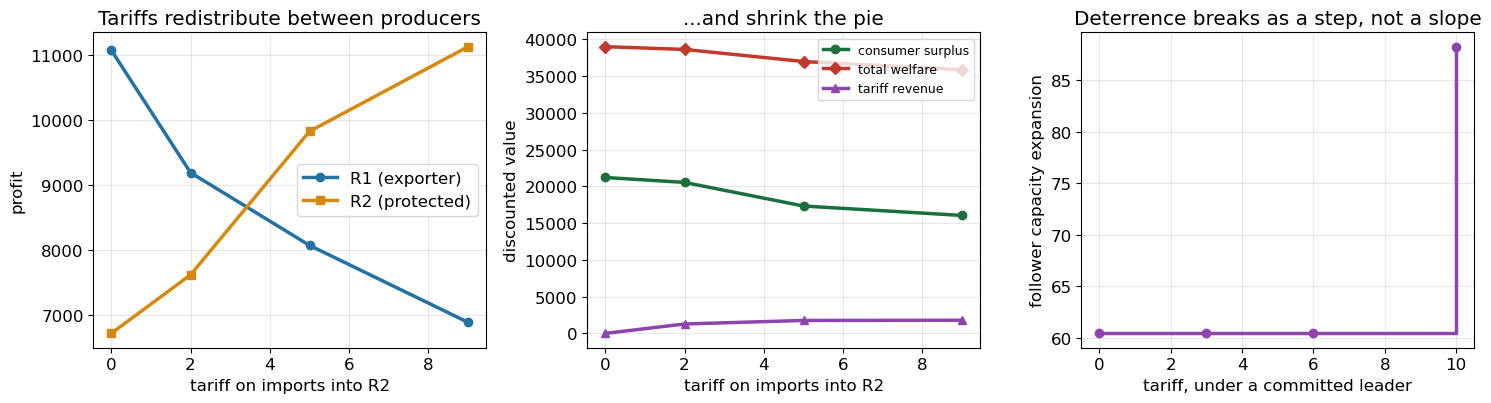

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].plot(tariffs.tariff, tariffs.R1_profit, 'o-', lw=2.5, color='#2471a3',
           label='R1 (exporter)')
ax[0].plot(tariffs.tariff, tariffs.R2_profit, 's-', lw=2.5, color='#d68910',
           label='R2 (protected)')
ax[0].set_xlabel('tariff on imports into R2'); ax[0].set_ylabel('profit')
ax[0].legend(); ax[0].set_title('Tariffs redistribute between producers')
ax[1].plot(tariffs.tariff, tariffs.consumer_surplus, 'o-', lw=2.5, color='#196f3d',
           label='consumer surplus')
ax[1].plot(tariffs.tariff, tariffs.welfare, 'D-', lw=2.5, color='#c0392b',
           label='total welfare')
ax[1].plot(tariffs.tariff, tariffs.gov_revenue, '^-', lw=2.5, color='#8e44ad',
           label='tariff revenue')
ax[1].set_xlabel('tariff on imports into R2'); ax[1].set_ylabel('discounted value')
ax[1].legend(fontsize=9); ax[1].set_title('...and shrink the pie')
ax[2].step(deterrence.tariff, deterrence.follower_capacity, where='post', lw=2.5,
           color='#8e44ad')
ax[2].plot(deterrence.tariff, deterrence.follower_capacity, 'o', color='#8e44ad')
ax[2].set_xlabel('tariff, under a committed leader')
ax[2].set_ylabel('follower capacity expansion')
ax[2].set_title('Deterrence breaks as a step, not a slope')
plt.tight_layout(); plt.show()

## 13. The agreement assertion

Sections 6 and 7 were built by hand, and `src/lithium/` holds the same models as
functions. **The same model exists twice, deliberately** — and deliberate
duplication with nothing comparing the copies is how a bug gets fixed in three
places out of four.

This cell imports the package, hands it the same instance dictionaries and the
same knobs, runs the same tariffed case as section 6.3, and asserts the two
objectives agree to $10^{-9}$.

There is an extra reason this one matters here. `lithium.regions.add_region`
carries the three policy instruments as **optional arguments**, so the package
folds the tariff into its transport term while this notebook subtracts a separate
duty from the objective. Those are different arrangements of the same arithmetic,
and this assertion is what proves they are the same arithmetic.

In [29]:
from lithium import (Instance, best_response_cournot, build_structure,
                     tariff_schedule, welfare as pkg_welfare)

nb_instance = Instance(
    regions=tuple(REGIONS), stages=tuple(STAGES),
    fixed=FIXED, unit=UNIT, opex=OPEX,
    legacy_cap=LEGACY_CAP, legacy_ret=LEGACY_RET,
    eta_ceil=ETA_CEIL, eta_base=ETA_BASE, alpha=ALPHA, beta=BETA, delta_bar=DELTA_BAR,
    demand_base=DEMAND_BASE, demand_growth=DEMAND_GROWTH, experience0=EXPERIENCE0,
)
nb_struct = build_structure(nb_instance, blocks=BLOCKS, dr=DR, life=LIFE, lead=LEAD,
                            cap_min=CAP_MIN, cap_max=CAP_MAX,
                            legacy_byr=LEGACY_BYR, eta_floor=ETA_FLOOR)

# the package builds the same schedule this notebook wrote out in section 6.1
assert tariff_schedule(REGIONS, TARIFF_RATE, on_imports_to=PROTECTED) == tariff5, \
    "the package's tariff_schedule does not match the schedule built by hand"

packaged = best_response_cournot(
    LEADER, zero_rival, nb_struct,
    a_int=A_INT, b_slp=B_SLP, nbp_rev=NBP_REV,
    learning='both', mipgap=MIPGAP_GAME,
    transport=TRANSPORT, pen_dispose=PEN_DISPOSE, price_fixed=PRICE_FIXED,
    capex_curve=(QBP, CBP), learn_stages=LEARN_STAGES,
    tiers=TIERS, n_tiers=N_TIERS, lag_years=LAG_YEARS,
    tariff=tariff5,
)

rel = abs(packaged.ObjVal - hand_built) / abs(hand_built)
print(f"notebook (section 6.3, by hand): {hand_built:,.9f}")
print(f"package  (lithium.games)       : {packaged.ObjVal:,.9f}")
assert rel < 1e-9, f"notebook and package disagree by {rel:.2e}"
print(f"\nnotebook and package agree to {rel:.1e}")
print("(the package folds the duty into its transport term; this notebook")
print(" subtracts it separately. Same arithmetic, and now proven so.)")

notebook (section 6.3, by hand): 18,043.881063451
package  (lithium.games)       : 18,043.881063451

notebook and package agree to 0.0e+00
(the package folds the duty into its transport term; this notebook
 subtracts it separately. Same arithmetic, and now proven so.)


### 13.1 And the welfare accounting

Section 7's `welfare` is small enough to look correct and small enough to get
wrong — the discounting is easy to drop, and the tariff-revenue term is easy to
sign the wrong way. Check it against the package's on the same equilibrium.

In [30]:
mine = welfare(res5['sales'], profits5, tariff5)     # the section 7.1 equilibrium
theirs = pkg_welfare(nb_struct, res5['sales'], profits5, b_slp=B_SLP, tariff=tariff5)

print(f"{'component':>18s} {'notebook':>14s} {'package':>14s} {'rel':>10s}")
for k in ('consumer_surplus', 'tariff_revenue', 'producer_profit', 'total'):
    rel_k = abs(mine[k] - theirs[k]) / max(abs(theirs[k]), 1e-12)
    print(f"{k:>18s} {mine[k]:14,.4f} {theirs[k]:14,.4f} {rel_k:10.1e}")
    assert rel_k < 1e-9, f"welfare component {k} disagrees by {rel_k:.2e}"
print("\nevery welfare component agrees")

         component       notebook        package        rel
  consumer_surplus    17,322.7109    17,322.7109    0.0e+00
    tariff_revenue     1,758.8507     1,758.8507    0.0e+00
   producer_profit    17,895.2294    17,895.2294    0.0e+00
             total    36,976.7910    36,976.7910    0.0e+00

every welfare component agrees


## 14. Summary

| Question | Answer |
|---|---|
| Does a tariff help the protected firm? | **Yes** — R2's profit rises 66%, 6,720.8 → 11,123.7 |
| Does it help the protected *country*? | **No** — welfare falls monotonically, 38,995.6 → 35,840.5 |
| Does tariff revenue keep rising? | It **flattens** — +1.7% between rates 5 and 9, while the rate nearly doubles |
| Tariff or quota? | **Tariff** — a quota of 10 gives comparable protection and collects zero, costing 449.3 of welfare |
| Does local content build domestic capability? | **Not at 70** — R2's own profit falls 21% while R1's rises |
| Can a tariff restore entry against a committed leader? | Only above a threshold: capacity is flat at 60.45 through rate 6, then steps to 88.27 at rate 10 |

### Formulation lessons

- **A tariff is a cost; a quota is a bound.** That structural difference, one
  line of model apart, is what makes their welfare arithmetic differ. The tariff
  adds **zero** constraints.
- **Attach policy from outside the model builder, not inside it.** Keeping the
  three levers out of `chain()` is what let section 6 show them as five readable
  lines instead of burying them in a wrapper.
- **Policy schedules should be built, not mutated.** The original notebook set
  three module-level dictionaries and relied on `clear_policy()` being called
  between scenarios; a forgotten call silently carried a tariff into the next
  sweep. Every schedule here is a fresh dictionary passed as an argument.
- **Sharp thresholds hide from coarse sweeps.** Both the local content floor and
  the deterrence tariff do nothing at all until they do everything. A sweep of
  two points would have reported the wrong conclusion for either.
- **Do not read a turning point off a flattening curve.** Tariff revenue flattens
  between rates 5 and 9; it never turns down in the range tested, and saying
  otherwise would be reading one past the data.

### Limitations, stated plainly

- **The government does not optimise.** Levers are exogenous and swept. Solving
  for a best policy would be a third level on top of an already-bilevel model.
- **Quota rents go nowhere.** A real government auctioning import licences would
  collect much of what this model hands to the firms as a higher price, which
  narrows the tariff-versus-quota gap that section 10 measures.
- **One protected market, one instrument at a time.** Real policy packages
  combine them, and interaction effects are not measured here.

### Things to try

Each is a one-line edit followed by *Run all*. The section 13 assertion should
stay green through every one.

- `TARIFF_LEVELS = [0, 4, 8, 12, 16]` — a finer sweep; find where revenue
  actually peaks rather than inferring it
- `PROTECTED = 'R1'` — protect the incumbent instead, and watch the welfare
  arithmetic change sign on who gains
- `LCR_LEVELS = [50, 55, 60, 65, 70]` — locate the threshold where the local
  content floor turns from harmless to harmful
- `DETERRENCE_TARIFFS = [7, 8, 9, 10]` — bracket the step in the follower's
  capacity more tightly
- In section 6.2, a quota *and* a tariff at once — the model supports it; the
  welfare comparison stops being clean, which is the point